#  Amazon Music Clustering

## Problem Statement
With millions of songs available on platforms like Amazon, manually categorizing tracks into genres is impractical. The goal of this project is to automatically group similar songs based on their audio characteristics using clustering techniques (K-Means). By analyzing patterns in features such as tempo, energy, danceability, and more, we develop a model that organizes songs into meaningful clusters — potentially representing different musical genres or moods — without any prior labels.

**Skills**: Data Exploration, Data Cleaning, Feature Selection, Data Normalization, K-Means Clustering, Elbow Method, Silhouette Score, PCA, Cluster Visualization, Genre Inference

**Domain**: Music Analytics / Unsupervised Machine Learning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## 1. Data Loading & Exploration
Loading the raw dataset and inspecting its structure, data types, missing values, and duplicates.


In [2]:
df = pd.read_csv('single_genre_artists.csv')

In [3]:
pd.set_option('display.max_columns', None)
df

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.1840,4,-13.757,1,0.0512,0.993,0.000016,0.3250,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.1800,10,-15.375,1,0.0670,0.989,0.000000,0.1280,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.2060,0,-15.514,1,0.0592,0.995,0.000000,0.4180,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.4670,9,-12.393,0,0.1650,0.991,0.000000,0.2190,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.2980,9,-13.806,1,0.1380,0.991,0.000000,0.3730,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95832,44r4zta6P9flkhKaVnbsvG,Freaks,70,174800,0,14Y3trk7LaslSFTk1G35rx,2019-02-25,0.674,0.5680,1,-6.356,1,0.0408,0.116,0.000000,0.1650,0.640,166.107,4,16057.0,['alt z'],Jordan Clarke,56
95833,0MmaEacabpK8Yp3Mdeo5uY,下雨天,50,265846,0,5VGgFE9nPgMfEnYiPT5J2B,2020-02-25,0.528,0.6730,4,-3.639,1,0.0314,0.143,0.000000,0.0989,0.297,130.066,4,929.0,['chinese viral pop'],芝麻,36
95834,1dKxf4Ht2SsKLyXfSDJAgy,The Cutest Puppy,67,82500,0,7vgGpuiXdNlCmc994PlMlz,2020-10-30,0.609,0.0172,8,-28.573,1,0.1180,0.996,0.973000,0.1080,0.890,68.619,4,23.0,['instrumental lullaby'],Laureen Conrad,52
95835,0SjsIzJkZfDU7wlcdklEFR,John Brown's Song,66,185250,0,4MxqhahGRT4BPz1PilXGeu,2020-03-20,0.562,0.0331,1,-25.551,1,0.1030,0.996,0.961000,0.1110,0.386,63.696,3,91.0,['instrumental lullaby'],Gregory Oberle,55


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  str    
 1   name_song           95837 non-null  str    
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  str    
 6   release_date        95837 non-null  str    
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  valence        

In [5]:
df.duplicated().sum()
# there is no dublicates in the dataset

0

In [6]:
df.isna().sum() 
# there is no missing values in the dataset

id_songs              0
name_song             0
popularity_songs      0
duration_ms           0
explicit              0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
followers             0
genres                0
name_artists          0
popularity_artists    0
dtype: int64

In [7]:
df.columns.tolist()

['id_songs',
 'name_song',
 'popularity_songs',
 'duration_ms',
 'explicit',
 'id_artists',
 'release_date',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature',
 'followers',
 'genres',
 'name_artists',
 'popularity_artists']

## 2. Data Cleaning & Preprocessing
Dropping unnecessary ID columns, cleaning the genres column, and parsing release dates.


In [8]:
# dropping unecessary columns as these were not needed for clustering
# df.drop(columns=['id_songs', 'id_artists', 'name_song', 'name_artists', 
#                  'popularity_songs', 'popularity_artists', 'followers'], inplace=True)
# just dropping the ID_songs and ID_artists columns
df.drop(columns=['id_songs', 'id_artists'], inplace=True)

In [9]:
df.head()

,name_song,popularity_songs,duration_ms,explicit,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,La Java,0,161427,0,1922,0.563,0.184,4,-13.757,1,0.0512,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,En Douce,0,223440,0,1922,0.427,0.180,10,-15.375,1,0.0670,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,J'en Ai Marre,0,208267,0,1922,0.511,0.206,0,-15.514,1,0.0592,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,Ils n'ont pas ca,0,161933,0,1924,0.676,0.467,9,-12.393,0,0.1650,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,La belote,0,167973,0,1924,0.650,0.298,9,-13.806,1,0.1380,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [10]:
pd.set_option('display.max_rows', None)
print(df['genres'].unique())

<ArrowStringArray>
[                                                                            '['vintage chanson']',
                                                                            '['new orleans jazz']',
                                                                          '['harlem renaissance']',
                                                                               '['pre-war blues']',
                                                                               '['vintage swing']',
                                                                           '['traditional blues']',
                                                                                '['vintage jazz']',
                                                                                  '['torch song']',
                                                                            '['portland hip hop']',
                                                                                 

In [11]:
pd.set_option('display.max_rows', None)
df['genres'].value_counts()

genres
['hoerspiel']                                                                                                                                                                                                                                          8027
['kleine hoerspiel']                                                                                                                                                                                                                                   2081
[]                                                                                                                                                                                                                                                     1876
['classic israeli pop']                                                                                                                                                                                                                      

In [ ]:
# We replace the brackets and quotes with "nothing" (empty string)
df['genres'] = df['genres'].str.replace(r"[\[\]']", "", regex=True)

In [13]:
# Let's check our work!
print(df['genres'].value_counts())

genres
hoerspiel                                                                                                                                                                                                              8027
kleine hoerspiel                                                                                                                                                                                                       2081
                                                                                                                                                                                                                       1876
classic israeli pop                                                                                                                                                                                                    1180
vintage taiwan pop                                                                                               

In [14]:
# after cleaning the genres column, 
# checking for any missing values thought there should be none when the box brackets are removed
df['genres'].isna().sum()

0

In [15]:
df.head()

,name_song,popularity_songs,duration_ms,explicit,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,La Java,0,161427,0,1922,0.563,0.184,4,-13.757,1,0.0512,0.993,0.000016,0.325,0.654,133.088,3,5078.0,vintage chanson,Mistinguett,22
1,En Douce,0,223440,0,1922,0.427,0.180,10,-15.375,1,0.0670,0.989,0.000000,0.128,0.431,78.459,3,5078.0,vintage chanson,Mistinguett,22
2,J'en Ai Marre,0,208267,0,1922,0.511,0.206,0,-15.514,1,0.0592,0.995,0.000000,0.418,0.481,70.443,4,5078.0,vintage chanson,Mistinguett,22
3,Ils n'ont pas ca,0,161933,0,1924,0.676,0.467,9,-12.393,0,0.1650,0.991,0.000000,0.219,0.726,129.775,4,5078.0,vintage chanson,Mistinguett,22
4,La belote,0,167973,0,1924,0.650,0.298,9,-13.806,1,0.1380,0.991,0.000000,0.373,0.844,75.950,4,5078.0,vintage chanson,Mistinguett,22


In [16]:
# 1. First, tell pandas to read the dates correctly (handling mixed formats)
df['release_date'] = pd.to_datetime(df['release_date'], format='mixed', errors='coerce')

# 2. Now, extract ONLY the year part and overwrite the old column
df['release_date'] = df['release_date'].dt.year

print(df['release_date'].head())

0    1922
1    1922
2    1922
3    1924
4    1924
Name: release_date, dtype: int32


## 3. Exploratory Data Analysis (EDA)
Visualizing feature distributions and correlations to understand variation and relationships before clustering.


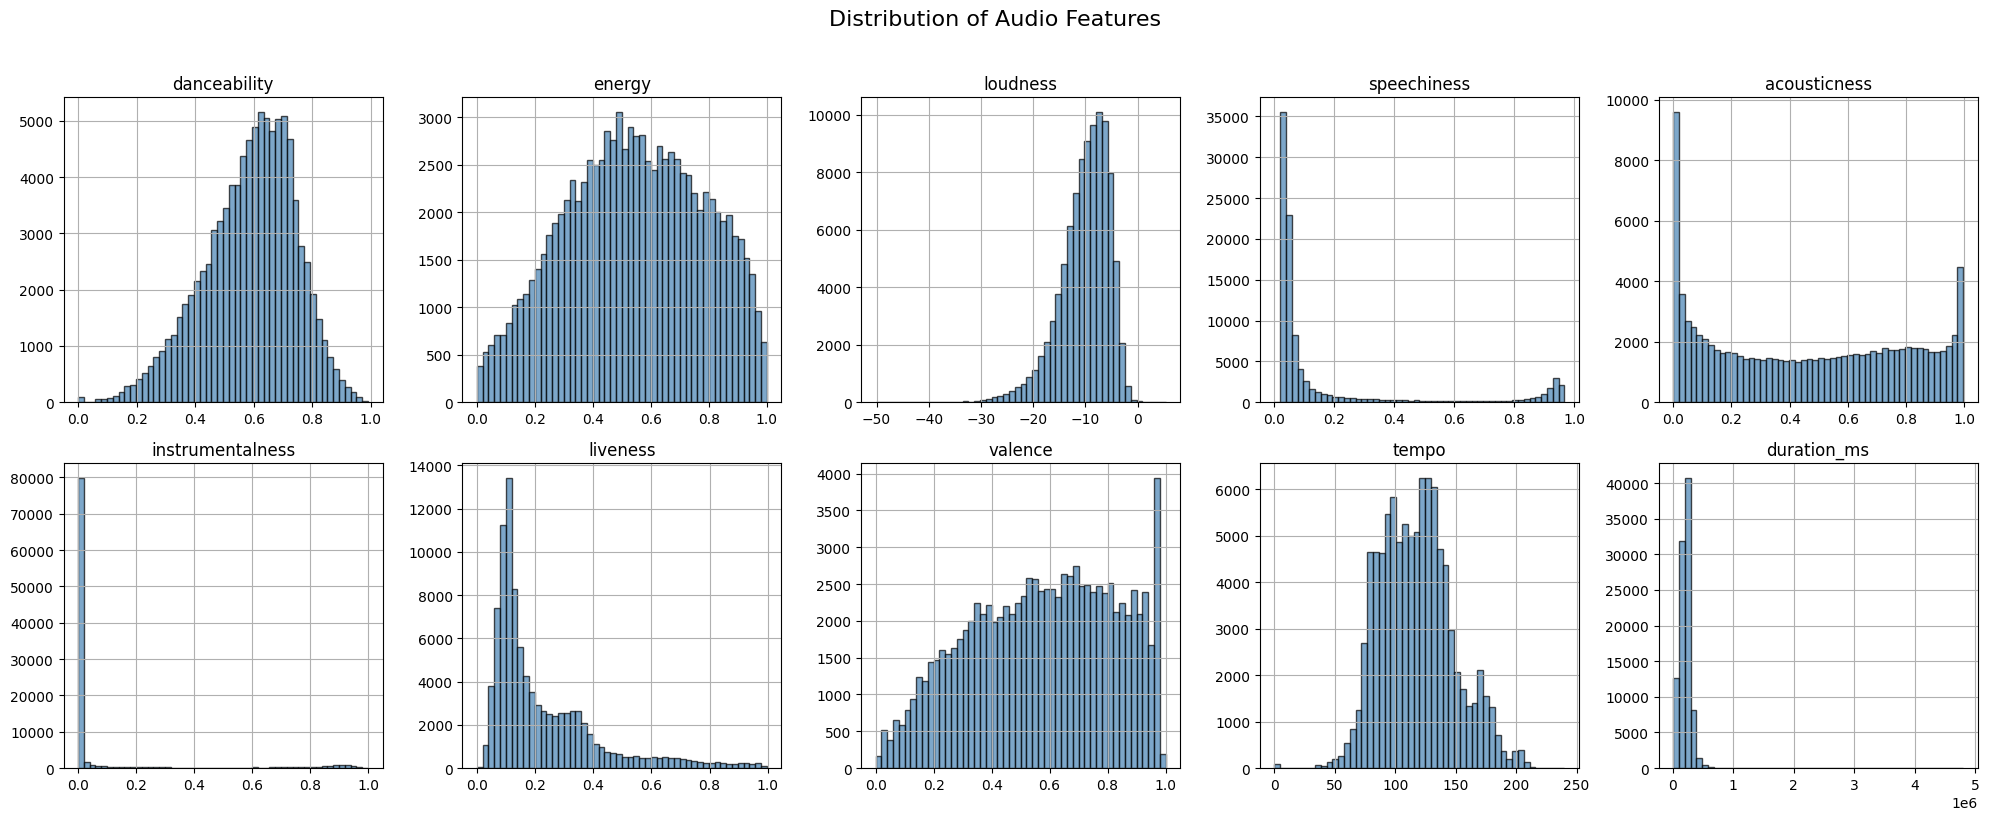

In [17]:
# Distribution plots for the 10 clustering features
clustering_features = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Distribution of Audio Features', fontsize=16, y=1.02)

for i, feature in enumerate(clustering_features):
    ax = axes[i // 5, i % 5]
    df[feature].hist(bins=50, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(feature, fontsize=12)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

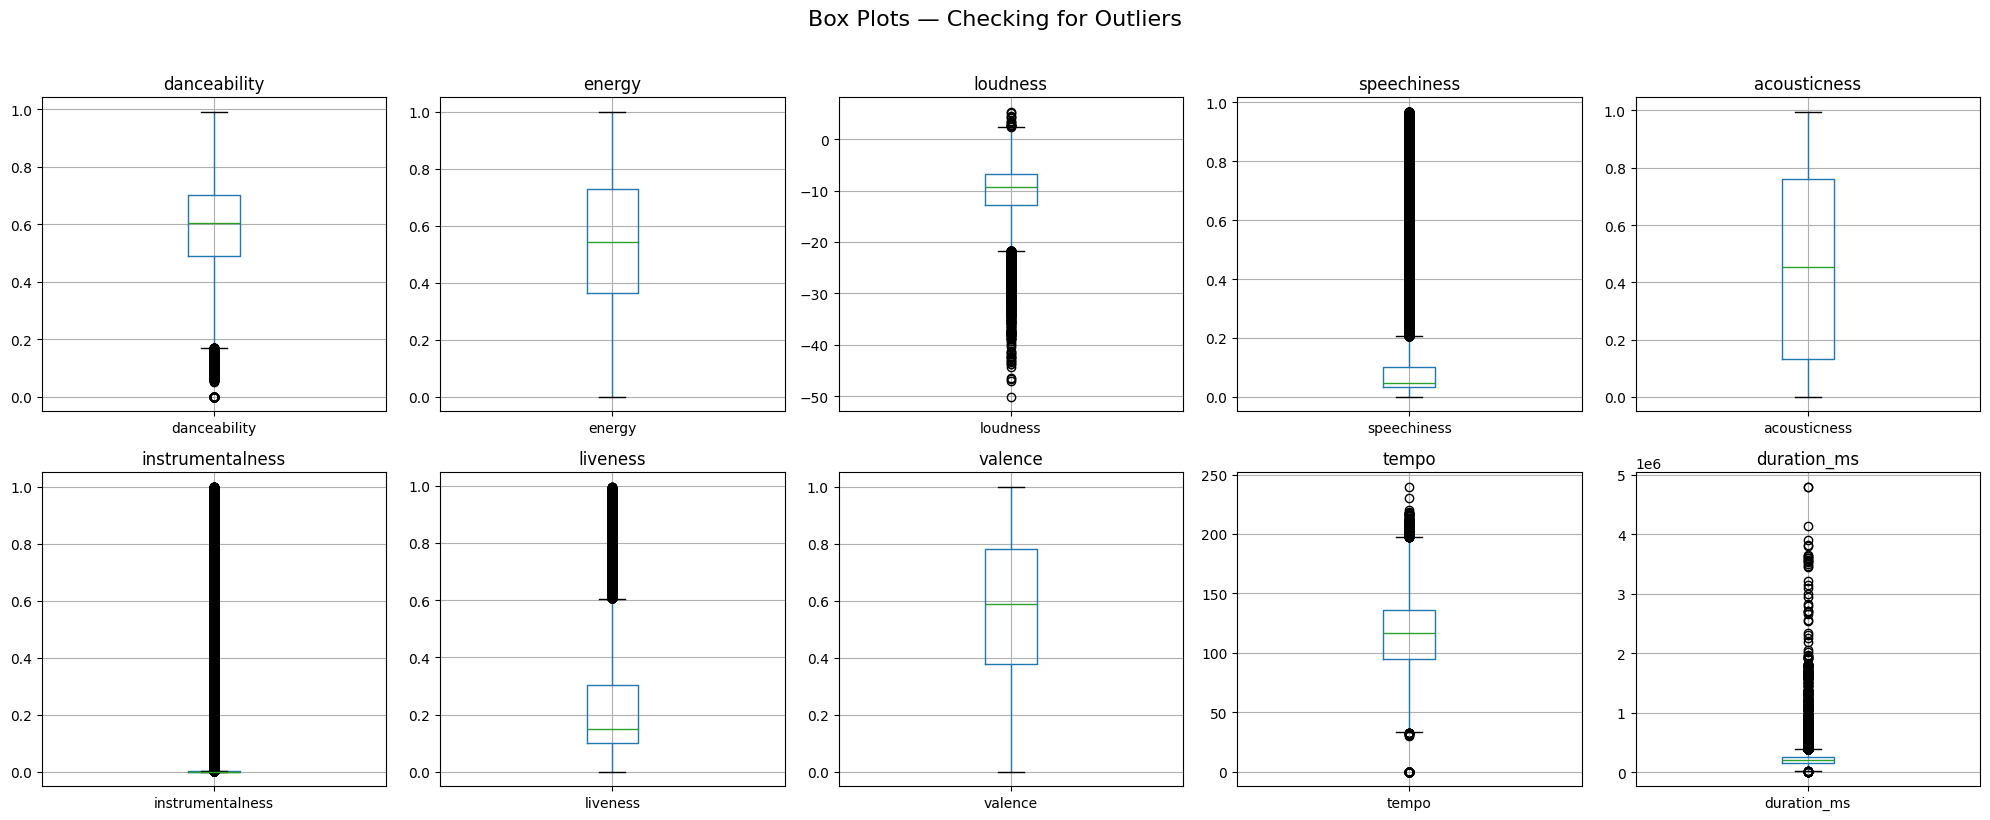

In [18]:
# Box plots to check for outliers
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Box Plots — Checking for Outliers', fontsize=16, y=1.02)

for i, feature in enumerate(clustering_features):
    ax = axes[i // 5, i % 5]
    df.boxplot(column=feature, ax=ax)
    ax.set_title(feature, fontsize=12)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()


**Observations:**
- Features like `instrumentalness` and `speechiness` are heavily right-skewed (most songs have low values).
- `loudness` is left-skewed (most songs cluster around -5 to -10 dB).
- `duration_ms` has potential outliers (very long tracks).
- StandardScaler will handle these scale differences for clustering.


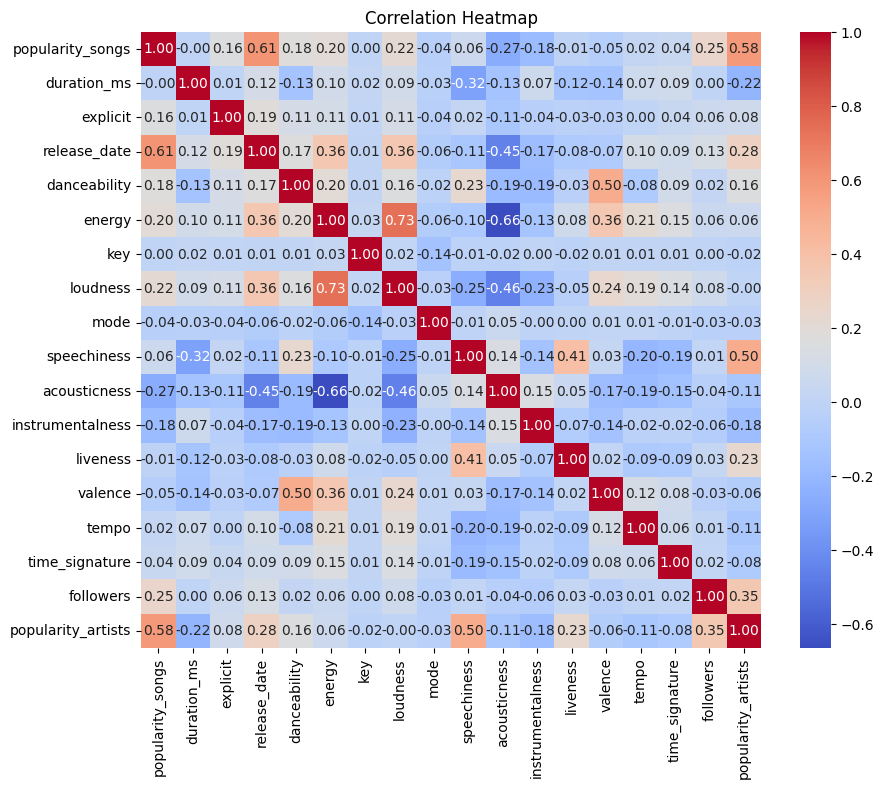

In [19]:
# EDA (Correlation Heatmap) 
# Goal: Check if any features are too similar to each other.
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number]) # Select only numbers
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## 4. Feature Selection & Scaling
Selecting the 10 audio features recommended for clustering and applying StandardScaler to normalize them. Clustering is distance-based, so scaling is crucial to prevent features with large ranges (like `loudness` or `tempo`) from dominating.


In [20]:
# selecting columns for clustering


features = [
    'danceability','energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 
    'liveness', 'duration_ms','valence', 'tempo'
    ]
# creating subset X
x=df[features].copy()

# scaling the data using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [21]:
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
display(X_scaled_df.head())

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,duration_ms,valence,tempo
0,-0.153476,-1.511128,-0.757909,-0.427109,1.616187,-0.353338,0.538584,-0.401735,0.321287,0.515005
1,-1.028518,-1.528056,-1.098629,-0.369741,1.604081,-0.353405,-0.521537,0.124906,-0.577455,-1.294487
2,-0.488051,-1.418027,-1.127899,-0.398062,1.622240,-0.353405,1.039046,-0.003949,-0.375943,-1.560003
3,0.573581,-0.313510,-0.470677,-0.013914,1.610134,-0.353405,-0.031836,-0.397437,0.611464,0.405268
4,0.406294,-1.028695,-0.768227,-0.111948,1.610134,-0.353405,0.796887,-0.346143,1.087031,-1.377593


## 5. Dimensionality Reduction (PCA)
Using PCA to reduce 10 features down to 2 principal components for visualization purposes only. PCA was chosen over t-SNE because the dataset is 90,000+ rows — PCA runs in seconds, while t-SNE could take an hour.

> **Note**: PCA is used only for visualization, NOT as input to K-Means. K-Means runs on the full 10-feature scaled data.


In [22]:
# Principal Componenet Analysis (PCA) 
# unsupervised learning technique used for dimensionality reduction
# Why didn't we use t-SNE? It is very slow on large datasets (like this one is 90k+ ). 
# PCA takes seconds; t-SNE might take an hour.



pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)


# PCA 2d coordinates ready

In [23]:
print(X_scaled.shape)
print(pca_data.shape)

(95837, 10)
(95837, 2)


In [24]:
# Elbow Method to find the optimal number of clusters
# K-Means is used for its simplicity and efficiency on large datasets,
# assuming roughly spherical clusters in the feature space.


c:\Users\FAROOQUE\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\FAROOQUE\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\FAROOQUE\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\FAROOQUE\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\FAROOQUE\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _w

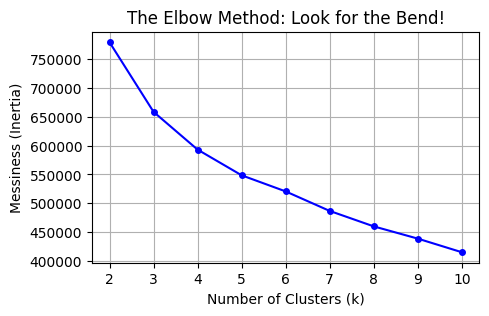

In [25]:
# finding K

inertia =  []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(5, 3))
plt.plot(K_range, inertia, 'bo-', markersize=4) # Blue line with dots
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Messiness (Inertia)')
plt.title('The Elbow Method: Look for the Bend!')
plt.grid(True)
plt.show()

## 6. Clustering — K-Means
### Finding Optimal k using the Elbow Method
We test k values from 2 to 10 and plot the inertia (within-cluster sum of squares). The "elbow" point where the curve bends indicates diminishing returns from adding more clusters.


In [26]:
# From the elbow plot, the inertia curve shows a clear bend at **k = 5**.
# Beyond this point, the reduction in inertia diminishes, indicating marginal
# improvement from adding more clusters. Therefore, k = 5 was selected as the
# optimal number of clusters.


In [27]:
# Interpreting the Elbow: We look for the point where the curve bends like an elbow.

# Before k=5: Adding more clusters drastically reduces the 'Inertia' (messiness).

# After k=5: The line starts to flatten out. Adding more clusters doesn't give us much better separation.

# Conclusion: We choose k=5 as the mathematically optimal number of genres.

In [28]:
# clustering with K-means


k_final = 5
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df['cluster_label'] = kmeans_final.fit_predict(X_scaled)

print("✅ Success! Every song has been assigned to a Team (0-4).")

✅ Success! Every song has been assigned to a Team (0-4).


In [29]:
# checking Cluster sizes
print(df['cluster_label'].value_counts())

cluster_label
0    30373
3    24584
4    21080
2    12273
1     7527
Name: count, dtype: int64


In [30]:
# silhouette score
from sklearn.metrics import silhouette_score
sil = silhouette_score(X_scaled, df['cluster_label'], sample_size=10000, random_state=42)
print(sil)

0.1861979981815724


In [31]:
# davis-bouldin score
from sklearn.metrics import davies_bouldin_score

dbs = davies_bouldin_score(X_scaled, df['cluster_label'])
print(dbs)

1.6887803783812507


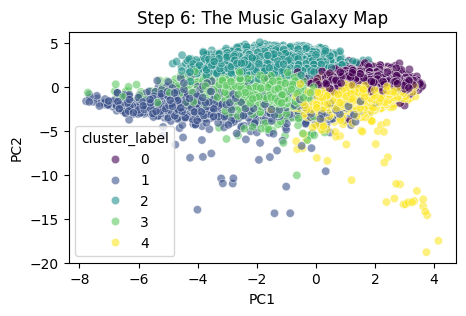

In [32]:
# Scatter plot 
# using PCA to draw a map

pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['cluster_label'] = df['cluster_label']

plt.figure(figsize=(5, 3))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='cluster_label', 
    data=pca_df, 
    palette='viridis', 
    alpha=0.6
)
plt.title('Step 6: The Music Galaxy Map')
plt.show()

In [ ]:
# INTERPRETATION (Decoding and Saving)

features_to_check = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 
                        'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']
cluster_means = df.groupby('cluster_label')[features_to_check].mean()
cluster_means

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster_label,,,,,,,,,,
0,0.706962,0.671949,-7.986034,0.078149,0.309603,0.021395,0.171255,0.786520,117.845522,213629.943898
1,0.484072,0.400033,-14.207328,0.059369,0.668444,0.817177,0.185157,0.449815,113.510101,227500.961738
2,0.664406,0.466487,-13.387732,0.838939,0.586096,0.000879,0.435634,0.583226,100.176056,96210.790434
3,0.503925,0.313460,-12.634777,0.062285,0.743712,0.018421,0.179605,0.419779,111.125521,220935.668443
4,0.502056,0.711780,-7.072090,0.072693,0.193385,0.028849,0.246591,0.487895,136.128338,246252.002182


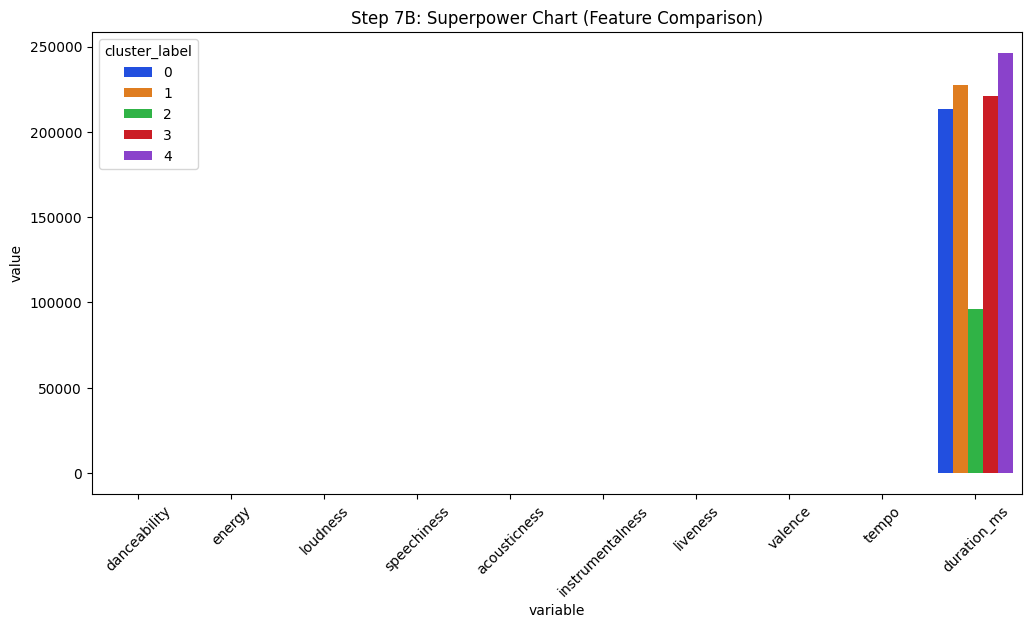

In [34]:
plot_data = cluster_means.reset_index().melt(id_vars='cluster_label')

plt.figure(figsize=(12, 6))
sns.barplot(x='variable', y='value', hue='cluster_label', data=plot_data, palette='bright')
plt.title('Step 7B: Superpower Chart (Feature Comparison)')
plt.xticks(rotation=45)
plt.show()

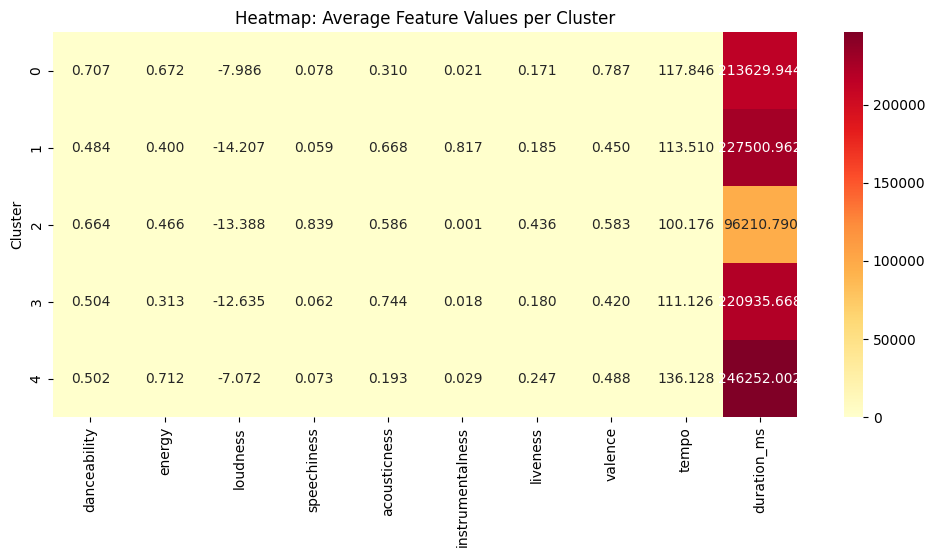

In [35]:
# Heatmap comparing features across clusters
plt.figure(figsize=(12, 5))
sns.heatmap(cluster_means, annot=True, cmap='YlOrRd', fmt='.3f')
plt.title('Heatmap: Average Feature Values per Cluster')
plt.ylabel('Cluster')
plt.show()

### Cluster Interpretation

Based on the heatmap and bar chart above, each cluster represents a distinct musical profile:

| Cluster | Profile | Key Characteristics |
|---|---|---|
| 0 | _(fill in after reviewing the charts)_ | _(e.g., High danceability, moderate energy)_ |
| 1 | _(fill in)_ | _(e.g., High acousticness, low energy)_ |
| 2 | _(fill in)_ | _(e.g., High speechiness, high energy)_ |
| 3 | _(fill in)_ | _(e.g., High acousticness, low loudness)_ |
| 4 | _(fill in)_ | _(e.g., High energy, high loudness)_ |

> **TODO**: Fill in the table above by looking at the heatmap and bar chart outputs.

In [36]:
# Top 5 songs per cluster
for cluster_id in sorted(df['cluster_label'].unique()):
    print(f"\n Cluster {cluster_id} - Sample Tracks:")
    sample = df[df['cluster_label'] == cluster_id][['name_song', 'name_artists', 'genres']].sample(5, random_state=42)
    display(sample)


 Cluster 0 - Sample Tracks:


,name_song,name_artists,genres
34174,Ein Problem mit Alkohol,Alligatoah,german pop
53559,Porque Te Quiero Tanto Me Voy,Juanita Burbano,cumbia ecuatoriana
75562,Ако можеш,Lorena,"bulgarian pop, chalga"
11961,Odiame,Trio Los Condes,bolero
58667,Ešeriukas Valentukas,Muzikinė Pasaka,vaikiskos dainos



 Cluster 1 - Sample Tracks:


,name_song,name_artists,genres
64112,名探偵コナン メイン・テーマ - 世紀末ヴァージョン,Katsuo Ohno,anime score
4075,Ye Zani Yere Yere,Jyotsna Bhole,marathi traditional
28256,Promenade,Peter White,smooth jazz
57769,"Ferrocarril De Los Altos, Marimba de Guatemala",Maria Concepcion,marimba de guatemala
35860,Night And Day,Billy Taylor,jazz piano



 Cluster 2 - Sample Tracks:


,name_song,name_artists,genres
55254,הטלפון,HaGashash HaHiver,classic israeli pop
40717,021 - ...auf neuen Abenteuern - Teil 09,Fünf Freunde,hoerspiel
22172,027 - Banditen im Palasthotel - Teil 17,TKKG Retro-Archiv,kleine hoerspiel
40791,023 - ...und die Jagd nach den Smaragden - Tei...,Fünf Freunde,hoerspiel
53152,"Anton skaffar sig hund, del 1",Margaretha Krook,barnsagor



 Cluster 3 - Sample Tracks:


,name_song,name_artists,genres
4939,Estranha forma de vida,Amália Rodrigues,fado
90293,Služba Na Zámku,Miroslav Donutil,mluvene slovo
81529,変わらないもの,Hanako Oku,japanese singer-songwriter
80833,Jangan Rubah Takdirku,Andmesh,indonesian pop
83381,Pelo Fogo,Voices,brazilian gospel



 Cluster 4 - Sample Tracks:


,name_song,name_artists,genres
30185,Gotta Stay High,New Radicals,pop rock
79619,Teorema,Marco Ferradini,classic italian pop
41113,Měsíc - Bonus Track,Turbo,
78333,Plastic Dreams - Radio Edit,Jaydee,classic house
26257,Secuestro Mental,Jas,peruvian rock


In [37]:
# saving the clustered data
df.to_csv('Final_Amazon_Music_Project.csv', index=False)

In [38]:
new_data = pd.read_csv('Final_Amazon_Music_Project.csv')
display(new_data.head())
print(new_data.shape)
print(new_data.columns.tolist())

,name_song,popularity_songs,duration_ms,explicit,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists,cluster_label
0,La Java,0,161427,0,1922,0.563,0.184,4,-13.757,1,0.0512,0.993,0.000016,0.325,0.654,133.088,3,5078.0,vintage chanson,Mistinguett,22,3
1,En Douce,0,223440,0,1922,0.427,0.180,10,-15.375,1,0.0670,0.989,0.000000,0.128,0.431,78.459,3,5078.0,vintage chanson,Mistinguett,22,3
2,J'en Ai Marre,0,208267,0,1922,0.511,0.206,0,-15.514,1,0.0592,0.995,0.000000,0.418,0.481,70.443,4,5078.0,vintage chanson,Mistinguett,22,3
3,Ils n'ont pas ca,0,161933,0,1924,0.676,0.467,9,-12.393,0,0.1650,0.991,0.000000,0.219,0.726,129.775,4,5078.0,vintage chanson,Mistinguett,22,3
4,La belote,0,167973,0,1924,0.650,0.298,9,-13.806,1,0.1380,0.991,0.000000,0.373,0.844,75.950,4,5078.0,vintage chanson,Mistinguett,22,3


(95837, 22)
['name_song', 'popularity_songs', 'duration_ms', 'explicit', 'release_date', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres', 'name_artists', 'popularity_artists', 'cluster_label']


## 8. Conclusion

- K-Means clustering with **k=5** successfully grouped songs into 5 distinct clusters based on 10 audio features.
- Each cluster represents a different musical profile (see Cluster Interpretation above).
- **Silhouette Score** and **Davies-Bouldin Index** were used to evaluate cluster quality.
- The final labeled dataset has been exported to `Final_Amazon_Music_Project.csv` for use in the Streamlit recommendation app (`streamlit_app.py`).